# Closed shops analysis

Dataset description says some stores were closed for refurbishment. Lets dive deeper and understand closed shops behavior.

In [1]:
from google.colab import drive
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
ROOT_PATH = Path("/content/drive/MyDrive/data/store-sales-forecasting/")
df = pd.read_csv(ROOT_PATH / "train.csv")
df = df.set_index('Date')
df.index = pd.to_datetime(df.index)

/tmp/ipykernel_2116/2917071980.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ROOT_PATH / "train.csv")


In [3]:
rows, columns = df.shape

print(f"Rows: {rows}\nColumns: {columns}")

Rows: 1017209
Columns: 8


Total sales in closed shops - 0
Closed stores ratio: 16.99%


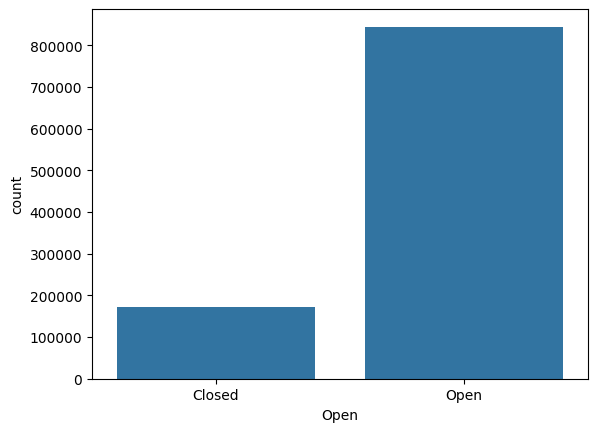

In [4]:
sns.countplot(df, x="Open")

print(f"Total sales in closed shops - {df[df["Open"] == 0]["Sales"].sum()}")
print(f"Closed stores ratio: {(df["Open"]==0).sum() / rows *100:.2f}%")

plt.xticks(ticks=[0, 1], labels=["Closed", "Open"])
plt.show()

We see that most part of the time stores are open. Only 17% of stores were closed for some reason along 2.5 years.
I want to understand are these stores were closed fully? If not, what is the "holiday" time?

In [5]:
def check_closed_shops_sold_later(df):
    """
    Check if stores sold something after being closed.
    Tracks all closing events (contiguous periods where Open==0).
    """
    closed_shop_ids = df.loc[df["Open"] == 0, "Store"].unique()
    results = []

    for store_id in closed_shop_ids:
        # Get store sales history (sorted by dates)
        store_df = df[df["Store"] == store_id].sort_index()
        is_closed = store_df["Open"] == 0

        # Detect contiguous closed periods
        period_id = (is_closed != is_closed.shift()).cumsum()
        
        for _, period_group in store_df.groupby(period_id): # Matching by DateTimeIndex
            if period_group["Open"].iloc[0] == 0:
                last_closed = period_group.index.max()

                after_df = store_df.loc[store_df.index > last_closed]
                sold_after = (after_df["Sales"] > 0).any()
                first_sale = after_df.loc[after_df["Sales"] > 0].index.min() if sold_after else pd.NaT

                results.append({
                    "Store": store_id,
                    "last_closed_date": last_closed,
                    "sold_after": sold_after,
                    "first_sale_after": first_sale,
                })

    return pd.DataFrame(results)

report_path = ROOT_PATH / "closed_report.csv"
if report_path.exists():
    closed_report = pd.read_csv(report_path)
    closed_report["last_closed_date"] = pd.to_datetime(closed_report["last_closed_date"])
    closed_report["first_sale_after"] = pd.to_datetime(closed_report["first_sale_after"])
else:
    closed_report = check_closed_shops_sold_later(df)
    closed_report.to_csv(report_path)

In [6]:
print(f"Shops that were closed at some point: {len(closed_report)}")
print(f"Shops that sold after closing: {closed_report['sold_after'].sum()}")
print(f"Shops that never sold after last closure: {(~closed_report['sold_after']).sum()}")

closed_df = closed_report.groupby(["last_closed_date", "first_sale_after"]).size() \
    .reset_index(name="num_closed_stores")
closed_df["closed_days"] = (closed_df["first_sale_after"] - closed_df["last_closed_date"]).dt.days
closed_df["DayOfWeek"] = closed_df["last_closed_date"].dt.day_of_week
print(f"\nUnique closing dates and number of closed stores:")
        
closed_df.sort_values(["closed_days", "num_closed_stores"], ascending=False)

Shops that were closed at some point: 161633
Shops that sold after closing: 161631
Shops that never sold after last closure: 2

Unique closing dates and number of closed stores:


,last_closed_date,first_sale_after,num_closed_stores,closed_days,DayOfWeek
81,2013-09-01,2013-09-25,1,24,6
150,2014-04-28,2014-05-05,1,7,0
199,2014-09-30,2014-10-06,1,6,1
43,2013-05-06,2013-05-11,1,5,0
167,2014-06-30,2014-07-05,1,5,0
...,...,...,...,...,...
256,2015-04-28,2015-04-29,1,1,1
259,2015-05-06,2015-05-07,1,1,2
264,2015-05-24,2015-05-25,1,1,6
271,2015-06-25,2015-06-26,1,1,3


We see that only 2 stores were never sold after closing (maybe these were under reconstruction while dataset formed)

We see that as the dataset tell us there are some stores that were under construction (I think 3-24 closed days period is about construction one)

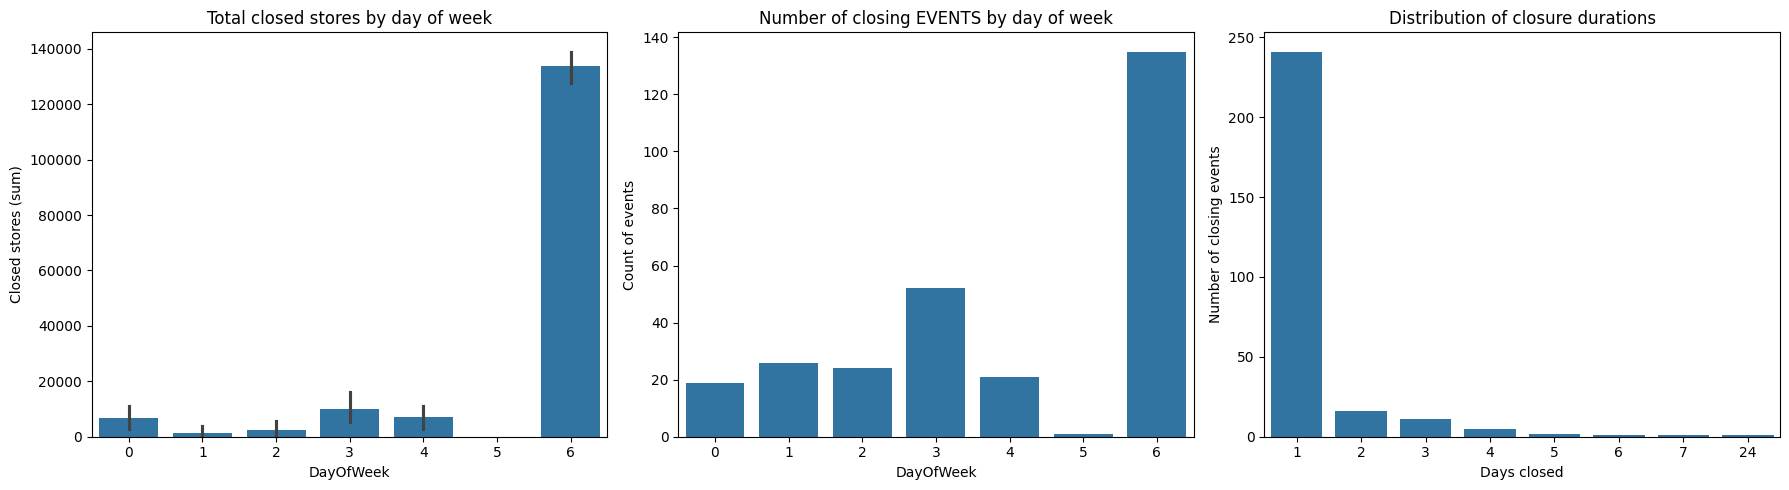

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(closed_df, y="num_closed_stores", x="DayOfWeek", ax=ax[0], estimator=sum)
ax[0].set_title("Total closed stores by day of week")
ax[0].set_ylabel("Closed stores (sum)")

sns.countplot(closed_df, x="DayOfWeek", ax=ax[1])
ax[1].set_title("Number of closing EVENTS by day of week")
ax[1].set_ylabel("Count of events")

sns.countplot(closed_df, x="closed_days", order=sorted(closed_df["closed_days"].unique()), ax=ax[2])
ax[2].set_title("Distribution of closure durations")
ax[2].set_ylabel("Number of closing events")
ax[2].set_xlabel("Days closed")
plt.tight_layout()
plt.show()

These plots tell us that most part of closing are 1 day period mostly seemed at sundays. These part tell us that close / open behavior is complex and mostly about Sundays / holidays closing instead of constructing ones.

I think I will not treat constructing stores as outliers because:
- There are few stores under construction. < 25 stores were closed more that 4 days
- Complex analytics for revealing constructing stores. Despite everything I have described and gather some analytics everything is theoretical. Analyzing data pipeline could show light on that.

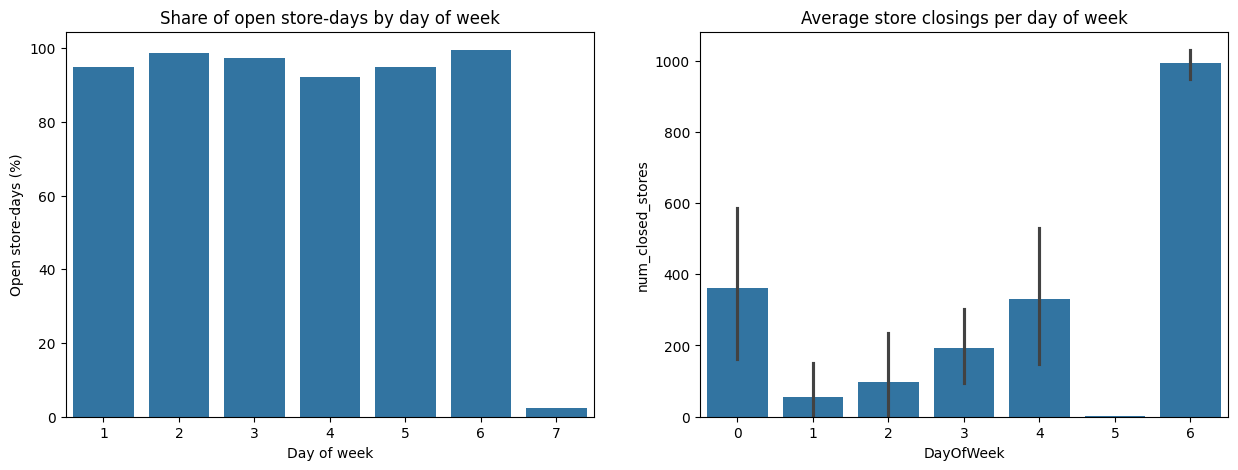

In [8]:
fig, ax = plt.subplots(1,2, figsize=(15,5))


open_share_by_dow = df.groupby("DayOfWeek")["Open"].mean() * 100
sns.barplot(x=open_share_by_dow.index, y=open_share_by_dow.values, ax=ax[0])
ax[0].set_title("Share of open store-days by day of week")
ax[0].set_xlabel("Day of week")
ax[0].set_ylabel("Open store-days (%)")

sns.barplot(closed_df, y="num_closed_stores", x="DayOfWeek", estimator="mean", ax=ax[1])
ax[1].set_title("Average store closings per day of week")

plt.show()

Important part. Not all stores are closed at sundays (new index labeling, where 1 - stands monday and 7 - sunday). Now is the small part what kind of the stores are opened at sundays.

## Are Sundays stores massive? Customer traffic comparison

All comparisons below use **open store-days only** (`Open == 1`), otherwise Sunday gets dragged down by the mass closures.

                  mean  median   count
DayOfWeek                             
1           855.444984   769.0  137560
2           769.986753   684.0  143961
3           740.598876   658.0  141936
4           755.569784   673.0  134644
5           781.771639   698.0  138640
6           660.177526   573.0  144058
7          1441.532424  1262.0    3593


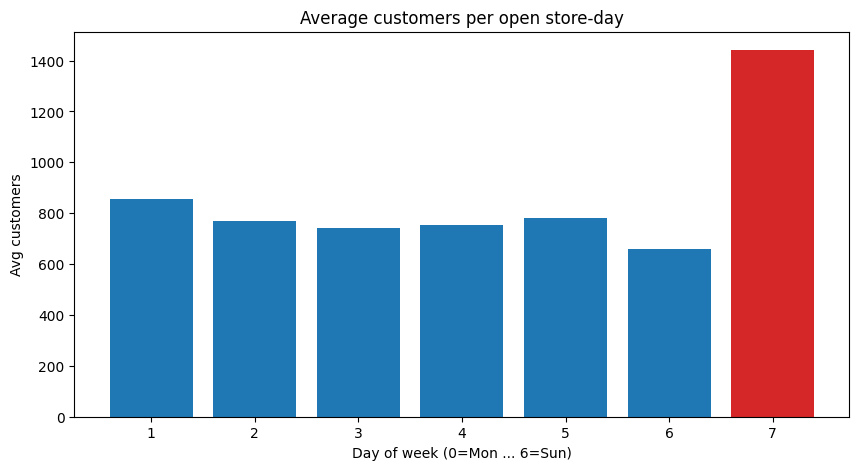

In [9]:
open_df = df[df["Open"] == 1]

dow_traffic = open_df.groupby("DayOfWeek")["Customers"].agg(["mean", "median", "count"])
print(dow_traffic)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["tab:red" if day == 7 else "tab:blue" for day in dow_traffic.index]
ax.bar(dow_traffic.index, dow_traffic["mean"], color=colors)
ax.set_title("Average customers per open store-day")
ax.set_xlabel("Day of week (0=Mon ... 6=Sun)")
ax.set_ylabel("Avg customers")
plt.show()

We see that despite the most amount of the stores are closed during sundays the customer traffic is the biggest one. My clue is that at sundays some big stores (hypermarkets, stores in shopping malls). That why the average traffic is high

In [10]:
sundays = closed_df[closed_df["DayOfWeek"] == 6]
sd_closing = sundays["last_closed_date"].nunique()

print(f"Total UNIQUE sundays, when all stores were closed: {sd_closing}")
print(f"Total UNIQUE sundays dates in dataset: {df[df["DayOfWeek"] == 6].index.unique().shape[0]}")

Total UNIQUE sundays, when all stores were closed: 132
Total UNIQUE sundays dates in dataset: 134


We see that most part of closings are at sundays. But actually not all stores are closed at sundays. Also we see additional 2 sundays were all stores were open

Mostly the key takeaway will be the fact that close label is pretty tricky: it will be difficult to understand stores that are closed for construction from weekdays / holidays closings
    - And actually do not need to: the amount of such stores is small